# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [4]:
# A) verificando os tipos de dados
print(f'###   Dados do preliminares do data frame:   ###')
print(df.info())
print('\n')
print(f'###   Verificando se existem valores nulos no data frame:   ###')
print(df.isnull().sum())

###   Dados do preliminares do data frame:   ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


###   Verificando se existem valores nulos no data frame:   ###
fixed 

## Avaliação

Com base na análise exploratória inicial do DataFrame, não foram identificados valores ausentes. A função df.info() indicou que todas as colunas possuem contagem completa de registros, sem a presença de valores nulos. Esse resultado foi confirmado pela função df.isnull().sum(), que retornou zero para todas as variáveis analisadas.

Dessa forma, conclui-se que o conjunto de dados está íntegro no que se refere à presença de valores faltantes, não sendo necessária a aplicação de técnicas de tratamento como remoção de registros ou imputação de valores nesta etapa da análise.

# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


## A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

In [5]:
# A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
# Identificação de outliers utilizando o método do IQR
outliers_summary = {}

for column in df.columns:
    if df[column].dtype != 'object':
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
        outliers_summary[column] = outliers_count

outliers_summary

{'fixed acidity': np.int64(49),
 'volatile acidity': np.int64(19),
 'citric acid': np.int64(1),
 'residual sugar': np.int64(155),
 'chlorides': np.int64(112),
 'free sulfur dioxide': np.int64(30),
 'total sulfur dioxide': np.int64(55),
 'density': np.int64(45),
 'pH': np.int64(35),
 'sulphates': np.int64(59),
 'alcohol': np.int64(13),
 'quality': np.int64(28)}

### Observação importante 
A decisão de não tratar os outliers nesta etapa também se justifica pelo fato de o Random Forest não depender de suposições de normalidade e ser pouco sensível a valores extremos.

## B) Verifique o balanceamento da váriavel Target.

In [13]:
# B) Verificando o balanceamento da variavel target (quality)
counts = df['quality'].value_counts().sort_index()
counts

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

<Axes: title={'center': 'Distribuição da Qualidade do Vinho'}, xlabel='Qualidade', ylabel='Contagem'>

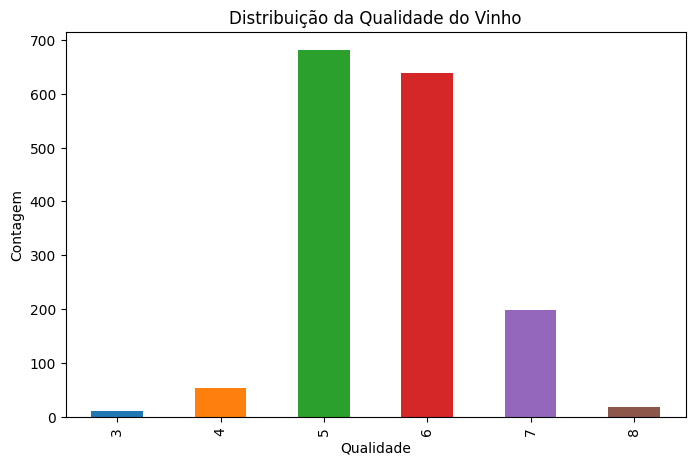

In [14]:
colors = plt.cm.tab10(range(len(counts)))
counts.plot(
    kind='bar',
    figsize=(8, 5),
    color=colors,
    title='Distribuição da Qualidade do Vinho',
    xlabel='Qualidade',
    ylabel='Contagem'
)

### Observação

A variável target `quality` apresenta uma distribuição não uniforme entre as classes, com maior concentração em valores intermediários. No entanto, o nível de desbalanceamento observado não é extremo.

O algoritmo Random Forest é reconhecido por sua robustez em relação a dados moderadamente desbalanceados, uma vez que utiliza múltiplas árvores treinadas a partir de amostras aleatórias e critérios de divisão que reduzem o viés em relação às classes majoritárias.

Dessa forma, optou-se por **não realizar técnicas de balanceamento** nesta etapa do pré-processamento, evitando a introdução de viés artificial nos dados. O desbalanceamento foi apenas identificado e documentado, ficando o tratamento condicionado a uma eventual análise de métricas mais sensíveis às classes minoritárias nas etapas posteriores de modelagem.

## C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

In [16]:
# C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.
correlacao = df.select_dtypes(include=['number']).corr()
correlacao

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


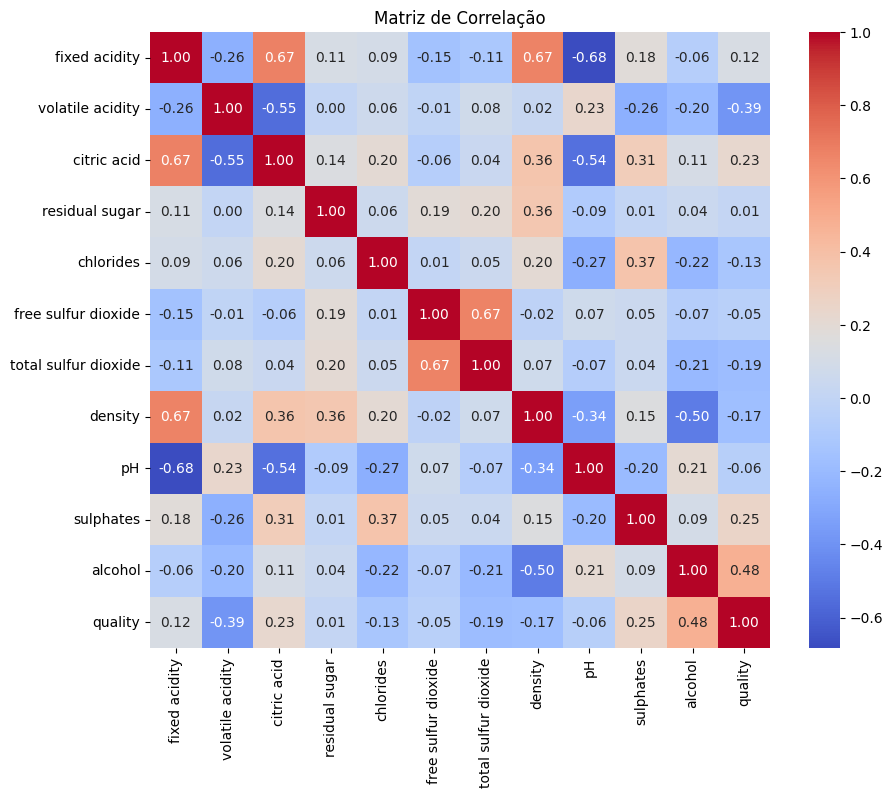

In [18]:
# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

## Variáveis mais relevantes
A análise de correlação entre as variáveis explicativas e a variável target `quality` indica que algumas características do vinho apresentam maior relação com a qualidade final. Dentre as correlações positivas, apontamos a variável `alcohol`, que apresenta a maior associação com a qualidade, seguida por `sulphates` e `citric acid`.

Em relação às correlações negativas, `volatile acidity` e `density` apresentam associação inversa com a variável target, indicando que valores elevados dessas características tendem a impactar negativamente a qualidade do vinho.

Essas variáveis foram consideradas mais relevantes nesta etapa exploratória, sendo utilizadas como base para a seleção de atributos e construção do modelo Random Forest nas etapas posteriores.

## D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)

In [19]:
# Selecionando as variáveis mais correlacionadas com a target
variavel_corr = [
    'alcohol',
    'sulphates',
    'citric acid',
    'volatile acidity',
    'density'
]

df_wine_corr = df[variavel_corr + ['quality']]
# novo dataframe com as variáveis selecionadas
df_wine_corr.head()

,alcohol,sulphates,citric acid,volatile acidity,density,quality
0,9.4,0.56,0.00,0.70,0.9978,5
1,9.8,0.68,0.00,0.88,0.9968,5
2,9.8,0.65,0.04,0.76,0.9970,5
3,9.8,0.58,0.56,0.28,0.9980,6
4,9.4,0.56,0.00,0.70,0.9978,5


# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


## A) Separe a base em X(Features) e Y(Target)

In [20]:
# Separando variáveis explicativas (X) e variável target (y)
X = df_wine_corr.drop('quality', axis=1)
y = df_wine_corr['quality']

## B) Separe a base em treino e teste.

In [21]:
# Separando os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


## A) Inicie e treine o modelo de Random Forest

In [22]:
# Inicializando o modelo Random Forest apenas com random_state
rf_model = RandomForestClassifier(random_state=42)

In [23]:
# Treinando o modelo
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## B) Aplique a base de teste o modelo.

In [24]:
# Aplicando o modelo treinado na base de teste
y_pred = rf_model.predict(X_test)

In [25]:
# Exibindo algumas previsões
y_pred[:10]

array([5, 5, 5, 5, 6, 5, 5, 5, 6, 6])

# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


## A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

In [32]:
# Avaliando o modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Acurácia: {accuracy:.2f}\n")
print(f"Relatório de Classificação:\n {report}\n")
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.66

Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.78      0.74       130
           6       0.63      0.67      0.65       132
           7       0.55      0.50      0.53        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.32      0.32      0.32       320
weighted avg       0.62      0.66      0.64       320


Matriz de Confusão:
 [[  0   0   1   0   0   0]
 [  0   0   6   4   0   0]
 [  0   0 101  28   1   0]
 [  0   0  33  88  11   0]
 [  0   0   1  19  21   1]
 [  0   0   0   0   5   0]]


O modelo Random Forest apresentou uma acurácia satisfatória(0.66), indicando uma boa proporção de previsões corretas em relação ao total de amostras avaliadas. 

Ao analisar o relatório de classificação, observa-se que as classes mais frequentes apresentam melhores valores de precision e recall (Classes 5, 6 e 7), enquanto classes com menor número de amostras tendem a apresentar desempenho inferior.

A matriz de confusão reforça essa análise ao mostrar maior concentração de acertos nas classes predominantes, evidenciando que o modelo aprende melhor os padrões associados às classes mais representadas no conjunto de dados.

## B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.

Sim, é possível observar que o modelo apresenta maior dificuldade em prever algumas classes específicas, principalmente aquelas com menor número de observações no conjunto de dados. Essa limitação está diretamente relacionada ao desbalanceamento da variável target, uma vez que o modelo tende a priorizar o aprendizado de padrões das classes mais frequentes.

Embora o Random Forest seja relativamente robusto a dados desbalanceados, o desempenho em classes minoritárias pode ser prejudicado. Estratégias como reamostragem, ajuste de pesos das classes ou até mesmo a transformação do problema em regressão poderiam ser exploradas em etapas futuras para melhorar o desempenho nessas classes.

# 6 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

## A) Defina o Grid de parametros que você quer testar

In [34]:
# Definindo o grid de hiperparâmetros para o Random Forest
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

## B) Inicie e Treine um novo modelo utilizando o random search.

In [35]:
# Inicializando o modelo base
rf = RandomForestClassifier(random_state=42)

# Configurando o Random Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    verbose=2,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

In [36]:
# Treinando o modelo com Random Search
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

## C) Avalie os resultados do modelo.

In [37]:
# Melhor modelo encontrado
best_model = random_search.best_estimator_

In [38]:
# Previsões com o novo modelo
y_pred_rs = best_model.predict(X_test)

In [42]:
# Avaliação

accuracy_be = accuracy_score(y_test, y_pred_rs)
report_be = classification_report(y_test, y_pred_rs, zero_division=0)
conf_matrix_be = confusion_matrix(y_test, y_pred_rs)


print(f"Acurácia: {accuracy_be:.2f}\n")
print(f"Relatório de Classificação:\n {report_be}\n")
print("Matriz de Confusão:\n", conf_matrix_be)

Acurácia: 0.66

Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.78      0.75       130
           6       0.63      0.66      0.64       132
           7       0.55      0.50      0.53        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.32      0.32      0.32       320
weighted avg       0.62      0.66      0.64       320


Matriz de Confusão:
 [[  0   0   1   0   0   0]
 [  0   0   6   4   0   0]
 [  0   0 102  27   1   0]
 [  0   0  34  87  11   0]
 [  0   0   0  20  21   1]
 [  0   0   0   0   5   0]]


## D) Você identificou melhorias no modelo após aplicar o random search? Justifique.

Embora o Random Search tenha identificado diferentes combinações de hiperparâmetros, a melhoria observada em relação ao modelo inicial foi imperceptível. 

Isso indica que o Random Forest com parâmetros padrão já apresentava um bom desempenho para este conjunto de dados. Ainda assim, o processo de otimização é relevante, pois confirma a robustez do modelo e fornece maior confiança nos resultados obtidos.

# 7 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

Para melhorar ainda mais o desempenho do modelo Random Forest, poderiam ser aplicadas técnicas de balanceamento da variável target, como oversampling ou undersampling, visando reduzir o impacto das classes minoritárias. Além disso, uma otimização mais aprofundada dos hiperparâmetros e a aplicação de engenharia de atributos poderiam contribuir para extrair padrões mais relevantes dos dados.